# Лабораторная работа №3
## Изображения и видео: извлечение разметки, COCO, обучение детектора

**Цель:** извлечь существующую разметку объектов из предоставленного видео `output.mp4`, оценить качество извлечения по IoU, сохранить в COCO, обучить детектор на основе `torchvision.models.detection` и оценить по mAP.

**Контекст** («Воровство разметки»). Не всегда есть возможность размечать фото или видео самостоятельно, но бывает, что под рукой — визуализация чужого результата. Мы восстанавливаем структурированные аннотации прямо из наложенных рамок.

---

### Теоретическая база

**Bounding Box** — ограничивающая рамка описывает прямоугольник вокруг объекта. В COCO: `[x_min, y_min, width, height]`. В PASCAL VOC: `(x1, y1, x2, y2)`.

**IoU (Intersection over Union)** — `IoU = Area(Intersection) / Area(Union)`. Применяется для сопоставления рамок, NMS и оценки качества детекции.

**Формат COCO** — JSON содержит три корневых ключа: `images`, `annotations`, `categories`. Каждая аннотация содержит `bbox`, `area`, `category_id`, `iscrowd`.

**mAP (mean Average Precision)** — стандарт COCO: усреднение AP по IoU-порогам 0.50:0.95 (шаг 0.05). Ключевая метрика качества детекции. Также используется mAP@0.5 (AP50).

**Архитектуры детекции (torchvision):**
- **Faster R-CNN** — двухэтапный детектор: RPN генерирует кандидатов, затем ROI-классификатор уточняет bbox. Точный, но тяжелее одноэтапных.
- **RetinaNet** — одноэтапный детектор с Focal Loss, устойчивый к дисбалансу фон/объект.
- **YOLO / SSD** — одноэтапные, оптимизированные на скорость.

**Методы извлечения чужой разметки из видео:**
1. **Frame Difference** — `output.mp4 − input.mp4` даёт маску линий рамок. Бинаризация, морфология, поиск контуров.
2. **HSV Color Segmentation** — пороги по цветам рамок (маджента/зелёный/синий/красный).
3. **Public CV API / Pretrained Detector** — YOLO или torchvision pretrained для сравнительного анализа.


## Часть 0. Импорты, установка и конфигурация

In [2]:
# ==========================================
# 0. Импорты, установка и конфигурация
# ==========================================

# %pip install torchmetrics opencv-python matplotlib tqdm pycocotools pandas seaborn -q
# %pip install ultralytics -q
# %pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124

import os, json, time, warnings, math, shutil, random
from typing import Dict, List, Tuple, Any
from pathlib import Path
from collections import defaultdict, Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from tqdm.auto import tqdm
from PIL import Image

import torch
import torchvision
from torchvision import transforms as T
import torchvision.transforms.functional as TF
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn, FasterRCNN_MobileNet_V3_Large_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader

try:
    from torchmetrics.detection.mean_ap import MeanAveragePrecision
except Exception as e:
    print(f'torchmetrics warning: {e}')
    MeanAveragePrecision = None

import xml.etree.ElementTree as ET

# Визуальный стиль
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# Пути
INPUT_VIDEO   = 'input.mp4'
OUTPUT_VIDEO  = 'output.mp4'
ANNOTATIONS   = 'annotations.xml'
FRAMES_IN     = 'frames_input'
FRAMES_OUT    = 'frames_output'
FRAMES_DIR    = 'frames'
COCO_DIR      = 'coco_dataset'
RESULTS_DIR   = 'results'

for d in [FRAMES_IN, FRAMES_OUT, FRAMES_DIR, COCO_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)


c:\cv_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## Часть 1. Декодирование видео в кадры

Используем OpenCV (`cv2.VideoCapture`). Важно проверить синхронность `input.mp4` и `output.mp4` по числу кадров и разрешению.

In [3]:
# === 1. Смотрим на annotations.xml ===
tree = ET.parse(ANNOTATIONS)
root = tree.getroot()
print("Root tag:", root.tag)
print("Root attribs:", root.attrib)
print("\nПервые 3 дочерних элемента:")
for i, child in enumerate(root):
    if i >= 3:
        break
    print(f"  tag={child.tag}, attrib={child.attrib}")
    for subchild in list(child)[:3]:
        print(f"    subtag={subchild.tag}, attrib={subchild.attrib}, text={subchild.text}")


Root tag: annotations
Root attribs: {}

Первые 3 дочерних элемента:
  tag=version, attrib={}
  tag=meta, attrib={}
    subtag=task, attrib={}, text=
      
  tag=track, attrib={'id': '0', 'label': 'car', 'source': 'manual'}
    subtag=box, attrib={'frame': '27', 'outside': '0', 'occluded': '0', 'keyframe': '1', 'xtl': '592.83', 'ytl': '0.00', 'xbr': '617.98', 'ybr': '12.08', 'z_order': '0'}, text=
    
    subtag=box, attrib={'frame': '28', 'outside': '0', 'occluded': '0', 'keyframe': '0', 'xtl': '592.83', 'ytl': '0.00', 'xbr': '618.36', 'ybr': '13.08', 'z_order': '0'}, text=
    
    subtag=box, attrib={'frame': '29', 'outside': '0', 'occluded': '0', 'keyframe': '0', 'xtl': '592.83', 'ytl': '0.00', 'xbr': '618.73', 'ybr': '14.09', 'z_order': '0'}, text=
    


In [4]:
# === 2. Базовая информация о видео ===
for name, path in [("input.mp4", INPUT_VIDEO),
                   ("output.mp4", OUTPUT_VIDEO)]:
    cap = cv2.VideoCapture(path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    print(f"{name}: {w}x{h}, {fps:.1f} fps, {total} кадров")


input.mp4: 1920x1080, 30.0 fps, 301 кадров
output.mp4: 1920x1080, 30.0 fps, 301 кадров


In [5]:
# === 3. Декодируем кадры из обоих видео ===
def extract_frames(video_path: str, out_dir: str, ext='jpg') -> dict:
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise IOError(f'Не удалось открыть {video_path}')
    fps = cap.get(cv2.CAP_PROP_FPS)
    w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_id = 0
    with tqdm(total=total, desc=f'Extract {os.path.basename(video_path)}') as pbar:
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            cv2.imwrite(os.path.join(out_dir, f'{frame_id:06d}.{ext}'), frame)
            frame_id += 1
            pbar.update(1)
    cap.release()
    return {'video': video_path, 'frames': frame_id, 'fps': fps, 'width': w, 'height': h}

meta_in  = extract_frames(INPUT_VIDEO, FRAMES_IN)
meta_out = extract_frames(OUTPUT_VIDEO, FRAMES_OUT)
print('Meta input :', meta_in)
print('Meta output:', meta_out)

assert meta_in['frames'] == meta_out['frames'], 'Число кадров не совпадает!'
assert (meta_in['width'], meta_in['height']) == (meta_out['width'], meta_out['height']), 'Разрешение не совпадает!'

N_FRAMES = meta_in['frames']
H, W = meta_in['height'], meta_in['width']
print(f'\nВидео синхронизированы. Кадров: {N_FRAMES}, разрешение: {W}x{H}')

# Также сохраняем кадры input в общую папку frames/ для обучения
for fid in range(N_FRAMES):
    src = os.path.join(FRAMES_IN, f'{fid:06d}.jpg')
    dst = os.path.join(FRAMES_DIR, f'frame_{fid:04d}.jpg')
    if not os.path.exists(dst):
        shutil.copy2(src, dst)
print(f"Скопировано кадров в {FRAMES_DIR}/: {len(os.listdir(FRAMES_DIR))}")


Extract output.mp4: 100%|██████████| 301/301 [00:03<00:00, 76.03it/s]

Meta input : {'video': 'input.mp4', 'frames': 301, 'fps': 30.0, 'width': 1920, 'height': 1080}
Meta output: {'video': 'output.mp4', 'frames': 301, 'fps': 30.0, 'width': 1920, 'height': 1080}

Видео синхронизированы. Кадров: 301, разрешение: 1920x1080
Скопировано кадров в frames/: 301


## Часть 2. Парсинг оригинальной разметки (annotations.xml)

Парсим Ground Truth из оригинального XML-файла разметки. Это нужно для:
1. Оценки качества извлечённой разметки по IoU.
2. Обучения модели детекции на точных аннотациях.

В данных два класса: **car** и **minivan**.

In [6]:
# === Парсим GT из annotations.xml ===
tree = ET.parse(ANNOTATIONS)
root = tree.getroot()

gt = defaultdict(list)
for track in root.findall('track'):
    label = track.attrib['label']
    for box in track.findall('box'):
        if box.attrib.get('outside', '0') == '1':
            continue
        fid = int(box.attrib['frame'])
        gt[fid].append({
            'label': label,
            'x1': float(box.attrib['xtl']), 'y1': float(box.attrib['ytl']),
            'x2': float(box.attrib['xbr']), 'y2': float(box.attrib['ybr']),
        })

print(f"Всего кадров с GT: {len(gt)}")
print(f"Всего аннотаций: {sum(len(v) for v in gt.values())}")
print(f"Классы: {set(b['label'] for boxes in gt.values() for b in boxes)}")

sample_frame = sorted(gt.keys())[10]
print(f"\nПример — кадр {sample_frame}: {gt[sample_frame][:3]}")

label2id = {'car': 1, 'minivan': 2}
id2label = {1: 'car', 2: 'minivan'}
NUM_CLASSES = 3  # фон + car + minivan


Всего кадров с GT: 901
Всего аннотаций: 9659
Классы: {'car', 'minivan'}

Пример — кадр 10: [{'label': 'car', 'x1': 220.5, 'y1': 525.94, 'x2': 406.75, 'y2': 707.5}, {'label': 'car', 'x1': 584.4, 'y1': 268.1, 'x2': 673.16, 'y2': 372.3}, {'label': 'car', 'x1': 525.3, 'y1': 143.49, 'x2': 588.37, 'y2': 209.1}]


## Часть 3. Извлечение bounding boxes из output.mp4

Реализуем **три метода** извлечения рамок и затем сравним их:
1. **Frame Difference** — разность кадров + морфология (основной метод).
2. **HSV Color Segmentation** — выделение цветных рамок по цвету.
3. **Public CV API** — YOLOv8 или torchvision pretrained Faster R-CNN для сравнительного анализа.

In [7]:
# ==========================================
# Вспомогательные функции
# ==========================================

def iou_box(boxA, boxB) -> float:
    """IoU для двух bbox в формате [x, y, w, h]."""
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[0] + boxA[2], boxB[0] + boxB[2])
    yB = min(boxA[1] + boxA[3], boxB[1] + boxB[3])
    inter = max(0.0, xB - xA) * max(0.0, yB - yA)
    areaA = boxA[2] * boxA[3]
    areaB = boxB[2] * boxB[3]
    union = areaA + areaB - inter + 1e-6
    return inter / union

def iou_xyxy(a, b):
    """IoU для двух bbox в формате (x1, y1, x2, y2)."""
    ix1 = max(a[0], b[0]); iy1 = max(a[1], b[1])
    ix2 = min(a[2], b[2]); iy2 = min(a[3], b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    if inter == 0:
        return 0.0
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    return inter / (area_a + area_b - inter)

def boxes_from_contours(contours, min_area=300, max_wh_ratio=6.0):
    boxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w * h < min_area:
            continue
        if w == 0 or h == 0:
            continue
        if max(w / h, h / w) > max_wh_ratio:
            continue
        boxes.append([int(x), int(y), int(w), int(h)])
    return boxes

def greedy_nms(boxes, iou_thresh=0.5):
    if not boxes:
        return []
    boxes = sorted(boxes, key=lambda b: b[2] * b[3], reverse=True)
    keep = []
    while boxes:
        cur = boxes.pop(0)
        keep.append(cur)
        boxes = [b for b in boxes if iou_box(cur, b) < iou_thresh]
    return keep

def match_boxes(gt_boxes, pred_boxes, iou_thresh=0.5):
    """Жадное сопоставление GT → pred по IoU (формат [x, y, w, h])."""
    if len(gt_boxes) == 0 and len(pred_boxes) == 0:
        return [], [], []
    if len(gt_boxes) == 0:
        return [], [], list(range(len(pred_boxes)))
    if len(pred_boxes) == 0:
        return [], list(range(len(gt_boxes))), []
    iou_mat = np.zeros((len(gt_boxes), len(pred_boxes)))
    for i, g in enumerate(gt_boxes):
        for j, p in enumerate(pred_boxes):
            iou_mat[i, j] = iou_box(g, p)
    matched_gt = set()
    matched_pred = set()
    pairs = []
    sorted_idx = sorted(
        [(iou_mat[i, j], i, j)
         for i in range(len(gt_boxes))
         for j in range(len(pred_boxes))],
        reverse=True
    )
    for score, i, j in sorted_idx:
        if score < iou_thresh:
            break
        if i not in matched_gt and j not in matched_pred:
            matched_gt.add(i)
            matched_pred.add(j)
            pairs.append((i, j, score))
    unmatched_gt = [i for i in range(len(gt_boxes)) if i not in matched_gt]
    unmatched_pred = [j for j in range(len(pred_boxes)) if j not in matched_pred]
    return pairs, unmatched_gt, unmatched_pred


### 3.1. Метод 1: Frame Difference (основной)

Разность пикселей между `output` и `input` показывает только добавленную визуализацию. 
Далее: grayscale → threshold → морфологическое закрытие (соединяет сегменты линий рамок) → поиск контуров.

**Преимущества:** не зависит от цвета рамок, устойчив к номерам (NMS отсекает мелкие).  
**Риски:** сжатие видео или лёгкий сдвиг кадров может дать шум.

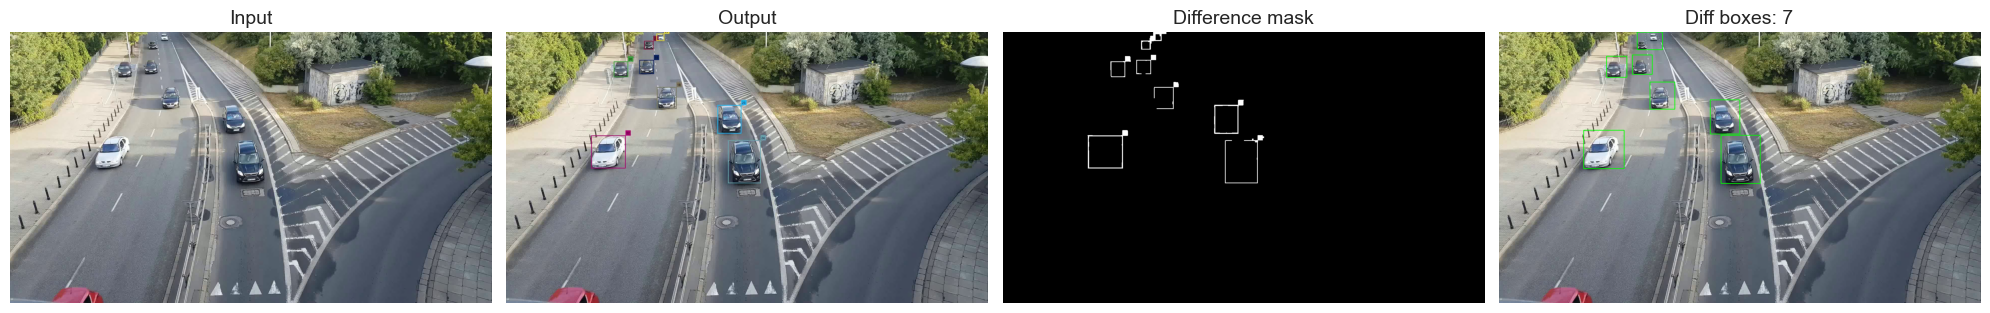

Пример bbox: [[884, 411, 156, 192], [337, 391, 161, 153], [841, 270, 118, 136], [601, 199, 99, 108], [550, 0, 101, 70]]


In [8]:
def extract_diff(frame_in, frame_out):
    d = cv2.absdiff(frame_in, frame_out)
    gray = cv2.cvtColor(d, cv2.COLOR_BGR2GRAY)
    _, th = cv2.threshold(gray, 20, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
    closed = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel, iterations=2)
    opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)
    contours, _ = cv2.findContours(opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = boxes_from_contours(contours, min_area=400)
    boxes = greedy_nms(boxes, iou_thresh=0.5)
    return boxes, opened

# Пример на первом кадре
sample_in  = cv2.imread(os.path.join(FRAMES_IN, '000000.jpg'))
sample_out = cv2.imread(os.path.join(FRAMES_OUT, '000000.jpg'))
sample_diff_boxes, sample_mask = extract_diff(sample_in, sample_out)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(cv2.cvtColor(sample_in, cv2.COLOR_BGR2RGB));  axes[0].set_title('Input')
axes[1].imshow(cv2.cvtColor(sample_out, cv2.COLOR_BGR2RGB)); axes[1].set_title('Output')
axes[2].imshow(sample_mask, cmap='gray');                     axes[2].set_title('Difference mask')
vis = sample_in.copy()
for b in sample_diff_boxes:
    x, y, w, h = b
    cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 2)
axes[3].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); axes[3].set_title(f'Diff boxes: {len(sample_diff_boxes)}')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()
print('Пример bbox:', sample_diff_boxes[:5])


### 3.2. Метод 2: HSV Color Segmentation

Если рамки имеют стабильные насыщенные цвета (маджента, зелёный, синий, красный), можно задать диапазоны HSV и объединить маски.

**Недостаток:** чувствителен к цветовым искажениям сжатия и пересечению с цветом объектов.

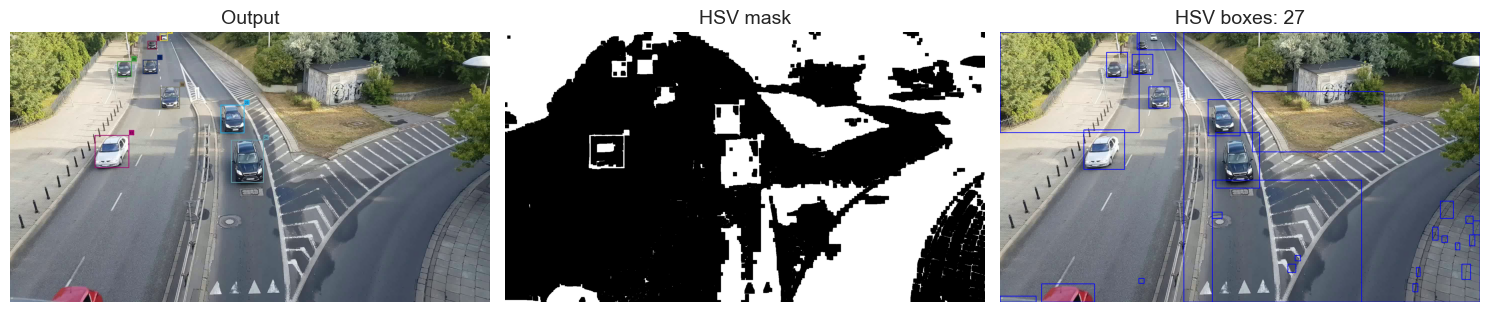

In [9]:
def extract_hsv(frame):
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    masks = []
    ranges = [
        ((35, 40, 40), (85, 255, 255)),    # зелёный
        ((90, 50, 50), (130, 255, 255)),   # синий
        ((15, 80, 80), (35, 255, 255)),    # жёлтый/оранжевый
        ((140, 50, 50), (179, 255, 255)),  # красный/розовый/маджента
        ((0, 50, 50),  (10, 255, 255)),    # красный lower
        ((148, 60, 150), (175, 255, 255)), # маджента (характерный цвет рамок)
    ]
    for lo, hi in ranges:
        masks.append(cv2.inRange(hsv, np.array(lo), np.array(hi)))
    combined = np.zeros_like(masks[0])
    for m in masks:
        combined = cv2.bitwise_or(combined, m)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
    combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, kernel, iterations=2)
    contours, _ = cv2.findContours(combined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = boxes_from_contours(contours, min_area=300)
    boxes = greedy_nms(boxes, iou_thresh=0.4)
    return boxes, combined

sample_hsv_boxes, sample_hsv_mask = extract_hsv(sample_out)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(sample_out, cv2.COLOR_BGR2RGB)); axes[0].set_title('Output')
axes[1].imshow(sample_hsv_mask, cmap='gray');                 axes[1].set_title('HSV mask')
vis2 = sample_in.copy()
for b in sample_hsv_boxes:
    x, y, w, h = b; cv2.rectangle(vis2, (x, y), (x + w, y + h), (255, 0, 0), 2)
axes[2].imshow(cv2.cvtColor(vis2, cv2.COLOR_BGR2RGB)); axes[2].set_title(f'HSV boxes: {len(sample_hsv_boxes)}')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()


### 3.3. Метод 3: Публичный CV API (Pretrained Detector)

Используем готовую нейросеть для детекции машин на оригинальных кадрах `input.mp4`.
- **YOLOv8** (ultralytics) — если доступен.
- **Fallback:** `torchvision.models.detection.fasterrcnn_resnet50_fpn` pretrained на COCO.

YOLOv8 (public API) загружен.


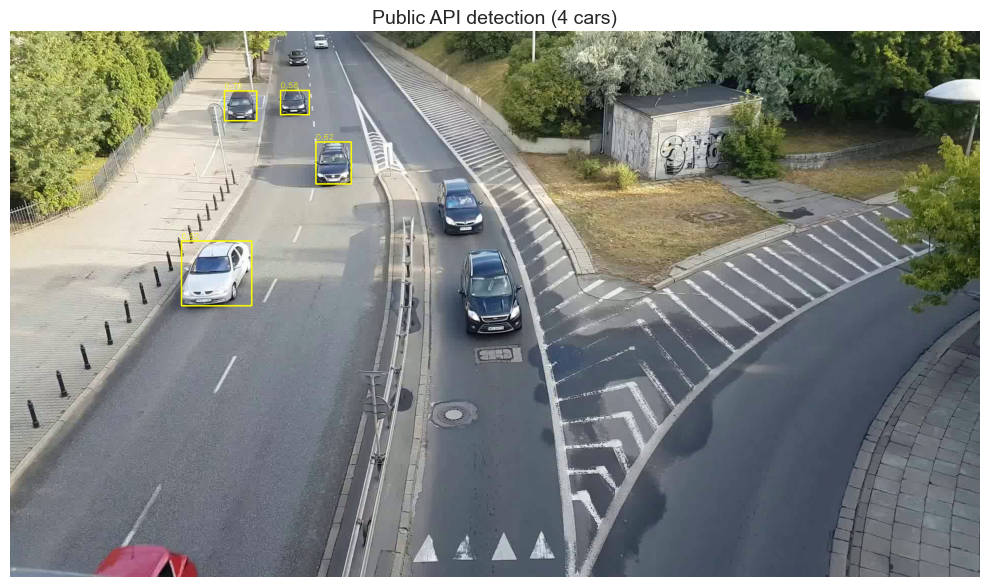

In [10]:
USE_YOLO = False
yolo_model = None

try:
    from ultralytics import YOLO
    yolo_model = YOLO('yolov8n.pt')
    USE_YOLO = True
    print('YOLOv8 (public API) загружен.')
except Exception as e:
    print(f'YOLOv8 не доступен ({e}). Fallback: torchvision Faster R-CNN pretrained.')

from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
pretrained_detector = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT).to(DEVICE).eval()

def detect_api(frame_bgr: np.ndarray, conf=0.4):
    boxes = []
    if USE_YOLO and yolo_model is not None:
        res = yolo_model.predict(frame_bgr, verbose=False, conf=conf)
        for r in res:
            for box in r.boxes:
                if int(box.cls.item()) == 2:  # car в COCO
                    x1, y1, x2, y2 = box.xyxy[0].tolist()
                    boxes.append([int(x1), int(y1), int(x2 - x1), int(y2 - y1), float(box.conf.item())])
    else:
        img = T.ToTensor()(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)).to(DEVICE)
        with torch.no_grad():
            pred = pretrained_detector([img])
        for i, lab in enumerate(pred[0]['labels'].cpu().numpy()):
            if lab == 3 and float(pred[0]['scores'].cpu().numpy()[i]) >= conf:  # car = 3 in COCO
                x1, y1, x2, y2 = pred[0]['boxes'].cpu().numpy()[i]
                boxes.append([int(x1), int(y1), int(x2 - x1), int(y2 - y1),
                              float(pred[0]['scores'].cpu().numpy()[i])])
    return boxes

sample_api_boxes = detect_api(sample_in)
vis3 = sample_in.copy()
for b in sample_api_boxes:
    x, y, w, h, conf = b
    cv2.rectangle(vis3, (x, y), (x + w, y + h), (0, 255, 255), 2)
    cv2.putText(vis3, f'{conf:.2f}', (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(vis3, cv2.COLOR_BGR2RGB))
plt.title(f'Public API detection ({len(sample_api_boxes)} cars)')
plt.axis('off'); plt.tight_layout(); plt.show()


## Часть 4. Оценка качества извлечения (IoU)

### 4.1 Извлечение bbox всеми методами на всех кадрах

In [11]:
FRAME_IDS = sorted([int(os.path.splitext(f)[0]) for f in os.listdir(FRAMES_IN) if f.endswith('.jpg')])

def extract_all(method_name: str, max_frames=None):
    results = {}
    ids = FRAME_IDS if max_frames is None else FRAME_IDS[:max_frames]
    for fid in tqdm(ids, desc=method_name):
        fin  = cv2.imread(os.path.join(FRAMES_IN,  f'{fid:06d}.jpg'))
        fout = cv2.imread(os.path.join(FRAMES_OUT, f'{fid:06d}.jpg'))
        if method_name == 'diff':
            b, _ = extract_diff(fin, fout)
            results[fid] = b
        elif method_name == 'hsv':
            b, _ = extract_hsv(fout)
            results[fid] = b
        elif method_name == 'api':
            b = detect_api(fin)
            results[fid] = [bb[:4] for bb in b]
        else:
            raise ValueError(method_name)
    return results

MAX_FRAMES = None  # None — все кадры
boxes_diff = extract_all('diff', max_frames=MAX_FRAMES)
boxes_hsv  = extract_all('hsv',  max_frames=MAX_FRAMES)
boxes_api  = extract_all('api',  max_frames=MAX_FRAMES)


api: 100%|██████████| 301/301 [00:09<00:00, 30.80it/s]


### 4.2 Сравнение методов между собой (pseudo-GT = Frame Diff)

Считаем Frame Difference наиболее точной реконструкцией исходной разметки. Для каждого кадра сопоставляем рамки жадным алгоритмом по IoU ≥ 0.5 и анализируем средний IoU, Precision и Recall.

IoU eval: 100%|██████████| 301/301 [00:00<00:00, 2365.03it/s]


        mean_iou  precision  recall  gt_count  pred_count
method                                                   
API        0.625      0.568   0.415     7.867       5.821
HSV        0.874      0.159   0.575     7.867      28.767


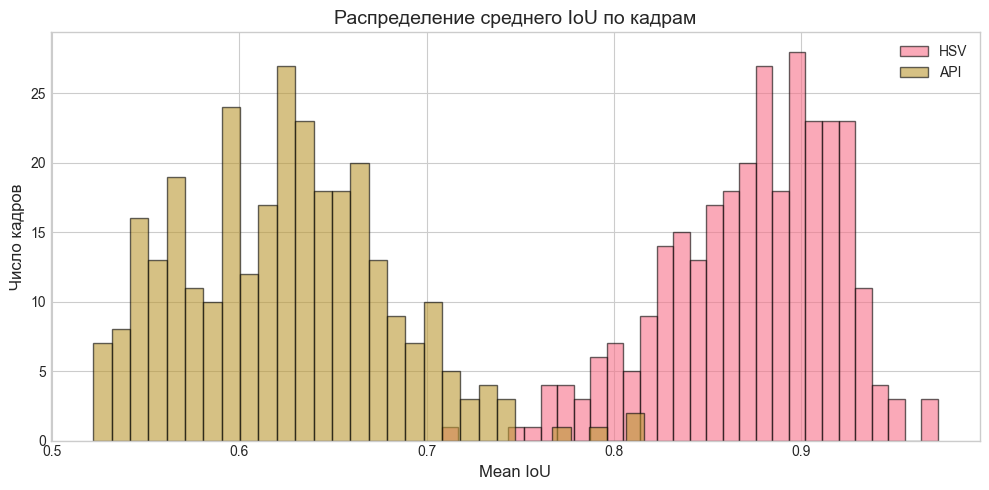

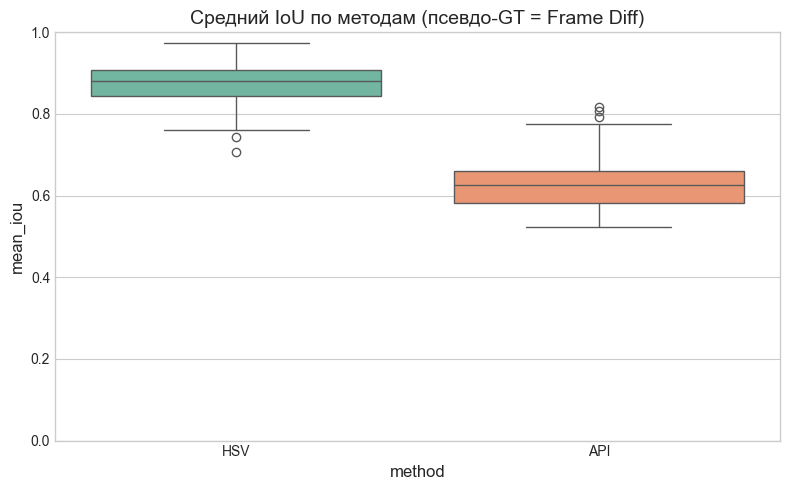

In [12]:
rows = []
for fid in tqdm(FRAME_IDS[:MAX_FRAMES] if MAX_FRAMES else FRAME_IDS, desc='IoU eval'):
    gt_boxes = boxes_diff[fid]
    for method_name, preds in [('HSV', boxes_hsv[fid]), ('API', boxes_api[fid])]:
        pairs, unmatched_gt, unmatched_pred = match_boxes(gt_boxes, preds, iou_thresh=0.5)
        ious = [score for _, _, score in pairs]
        mean_iou = float(np.mean(ious)) if ious else 0.0
        prec = len(pairs) / (len(pairs) + len(unmatched_pred)) if (len(pairs) + len(unmatched_pred)) > 0 else 0
        rec  = len(pairs) / (len(pairs) + len(unmatched_gt))   if (len(pairs) + len(unmatched_gt)) > 0 else 0
        rows.append({
            'frame': fid,
            'method': method_name,
            'gt_count': len(gt_boxes),
            'pred_count': len(preds),
            'matched': len(pairs),
            'mean_iou': mean_iou,
            'precision': prec,
            'recall': rec,
        })

df_iou = pd.DataFrame(rows)
print(df_iou.groupby('method')[['mean_iou', 'precision', 'recall', 'gt_count', 'pred_count']].mean().round(3))

# Распределение IoU
plt.figure(figsize=(10, 5))
for method_name in df_iou['method'].unique():
    subset = df_iou[df_iou['method'] == method_name]
    plt.hist(subset['mean_iou'], bins=30, alpha=0.6, label=method_name, edgecolor='black')
plt.title('Распределение среднего IoU по кадрам'); plt.xlabel('Mean IoU'); plt.ylabel('Число кадров')
plt.legend(); plt.tight_layout(); plt.show()

# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_iou, x='method', y='mean_iou', hue='method', palette='Set2', legend=False)
plt.title('Средний IoU по методам (псевдо-GT = Frame Diff)'); plt.ylim(0, 1)
plt.tight_layout(); plt.show()


### 4.3 Оценка качества извлечения по оригинальной разметке (annotations.xml)

Сравниваем извлечённые рамки (diff-метод) с оригинальным GT из `annotations.xml`. Это ключевая проверка качества «воровства разметки».

In [13]:
# === Извлекаем боксы diff-методом на всех 301 кадрах ===
cap_out = cv2.VideoCapture(OUTPUT_VIDEO)
cap_in  = cv2.VideoCapture(INPUT_VIDEO)
total_frames = int(cap_out.get(cv2.CAP_PROP_FRAME_COUNT))

extracted = {}
for fid in range(total_frames):
    cap_out.set(cv2.CAP_PROP_POS_FRAMES, fid)
    cap_in.set(cv2.CAP_PROP_POS_FRAMES, fid)
    _, f_out = cap_out.read()
    _, f_in  = cap_in.read()
    extracted[fid] = extract_diff(f_in, f_out)[0]
    if fid % 50 == 0:
        print(f"  кадр {fid}/{total_frames}  боксов: {len(extracted[fid])}")
cap_out.release()
cap_in.release()
print(f"Готово. Всего боксов извлечено: {sum(len(v) for v in extracted.values())}")


  кадр 0/301  боксов: 7
  кадр 50/301  боксов: 9
  кадр 100/301  боксов: 6
  кадр 150/301  боксов: 5
  кадр 200/301  боксов: 7
  кадр 250/301  боксов: 9
  кадр 300/301  боксов: 13
Готово. Всего боксов извлечено: 2352


In [14]:
# === Диагностика: какие кадры есть в GT и в видео ===
video_frames = set(range(N_FRAMES))
gt_frames    = set(gt.keys())
overlap      = video_frames & gt_frames

print(f"Кадров в видео:       {len(video_frames)}  (0–{N_FRAMES-1})")
print(f"Кадров с GT:          {len(gt_frames)}  ({min(gt_frames)}–{max(gt_frames)})")
print(f"Пересечение:          {len(overlap)} кадров")
print(f"GT боксов в overlap:  {sum(len(gt[f]) for f in overlap)}")
print(f"Извлечено боксов:     {sum(len(extracted[f]) for f in overlap)}")

# === IoU с оригинальным GT (только overlap-кадры) ===
tp = fp = fn = 0
all_ious = []
per_frame_iou = []

for fid in sorted(overlap):
    gt_boxes = gt[fid]
    preds = extracted[fid]
    used = set()
    frame_ious = []
    for pred in preds:
        # pred в формате [x, y, w, h] → конвертируем в (x1, y1, x2, y2)
        px1, py1 = pred[0], pred[1]
        px2, py2 = pred[0] + pred[2], pred[1] + pred[3]
        best, bj = 0, -1
        for j, g in enumerate(gt_boxes):
            if j in used:
                continue
            v = iou_xyxy((px1, py1, px2, py2), (g['x1'], g['y1'], g['x2'], g['y2']))
            if v > best:
                best, bj = v, j
        if best >= 0.5:
            tp += 1; used.add(bj); all_ious.append(best); frame_ious.append(best)
        else:
            fp += 1
    fn += len(gt_boxes) - len(used)
    if frame_ious:
        per_frame_iou.append(np.mean(frame_ious))

prec = tp / (tp + fp) if tp + fp > 0 else 0
rec  = tp / (tp + fn) if tp + fn > 0 else 0
f1   = 2 * prec * rec / (prec + rec) if prec + rec > 0 else 0

print(f"\n=== Метрики (только overlap-кадры, сравнение с оригинальным GT) ===")
print(f"TP={tp}  FP={fp}  FN={fn}")
print(f"Precision = {prec:.3f}")
print(f"Recall    = {rec:.3f}")
print(f"F1        = {f1:.3f}")
print(f"Mean IoU (matched)   = {np.mean(all_ious):.3f}")
print(f"Mean per-frame IoU   = {np.mean(per_frame_iou):.3f}")


Кадров в видео:       301  (0–300)
Кадров с GT:          901  (0–900)
Пересечение:          301 кадров
GT боксов в overlap:  3647
Извлечено боксов:     2352

=== Метрики (только overlap-кадры, сравнение с оригинальным GT) ===
TP=1642  FP=710  FN=2005
Precision = 0.698
Recall    = 0.450
F1        = 0.547
Mean IoU (matched)   = 0.682
Mean per-frame IoU   = 0.681



Распределение IoU по совпавшим парам:
       <0.3:    0  
    0.3-0.5:    0  
    0.5-0.6:  581  ██████████████████████████████████████████████████████████
    0.6-0.7:  311  ███████████████████████████████
    0.7-0.8:  373  █████████████████████████████████████
    0.8-0.9:  316  ███████████████████████████████
    0.9-1.0:   61  ██████


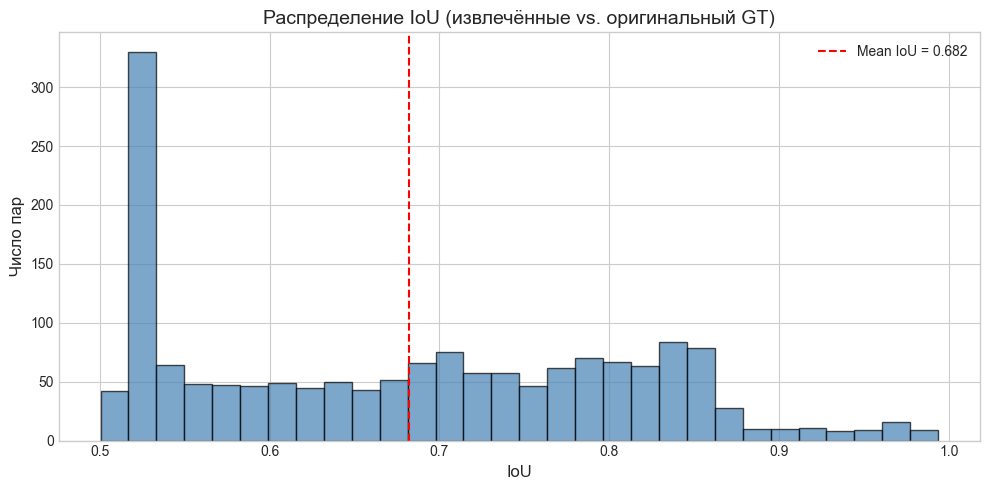

In [15]:
# === Гистограмма IoU по совпавшим парам ===
bins = [0, 0.3, 0.5, 0.6, 0.7, 0.8, 0.9, 1.01]
labels_hist = ['<0.3', '0.3-0.5', '0.5-0.6', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']
counts, _ = np.histogram(all_ious, bins=bins)

print("\nРаспределение IoU по совпавшим парам:")
for lbl, cnt in zip(labels_hist, counts):
    bar = '█' * (cnt // 10)
    print(f"  {lbl:>9}: {cnt:4d}  {bar}")

plt.figure(figsize=(10, 5))
plt.hist(all_ious, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(np.mean(all_ious), color='red', linestyle='--', label=f'Mean IoU = {np.mean(all_ious):.3f}')
plt.title('Распределение IoU (извлечённые vs. оригинальный GT)')
plt.xlabel('IoU'); plt.ylabel('Число пар'); plt.legend()
plt.tight_layout(); plt.show()


## Часть 5. Формирование COCO датасета

Сохраняем извлечённую разметку (Frame Diff) в формат COCO.

Для **обучения детектора** используем оригинальную разметку из `annotations.xml` с двумя классами (`car`, `minivan`). Это позволяет обучить модель на точных аннотациях.

Разделение: **train / val = 80% / 20%** (random split с `RANDOM_STATE`).

In [16]:
# === Извлечённая разметка в COCO (для проверки) ===
categories = [
    {"id": 1, "name": "car",     "supercategory": "vehicle"},
    {"id": 2, "name": "minivan", "supercategory": "vehicle"},
]

images_coco = []
annotations_coco = []
ann_id = 1
for fid in range(N_FRAMES):
    images_coco.append({
        "id": fid,
        "file_name": f"frame_{fid:04d}.jpg",
        "width": W,
        "height": H,
    })
    for (x, y, w, h) in extracted.get(fid, []):
        annotations_coco.append({
            "id": ann_id,
            "image_id": fid,
            "category_id": 1,  # diff не различает классы → car по умолчанию
            "bbox": [x, y, w, h],
            "area": w * h,
            "iscrowd": 0,
        })
        ann_id += 1

extracted_coco = {"images": images_coco, "annotations": annotations_coco, "categories": categories}
with open('extracted_coco.json', 'w') as f:
    json.dump(extracted_coco, f, indent=2)
print(f"Сохранено → extracted_coco.json  ({ann_id - 1} аннотаций, {len(images_coco)} изображений)")


Сохранено → extracted_coco.json  (2352 аннотаций, 301 изображений)


In [17]:
# === COCO из оригинального GT (для обучения) ===
frame_ids_all = list(range(N_FRAMES))
random.shuffle(frame_ids_all)
split = int(0.8 * len(frame_ids_all))
train_ids = sorted(frame_ids_all[:split])
val_ids   = sorted(frame_ids_all[split:])
print(f"Train: {len(train_ids)} кадров | Val: {len(val_ids)} кадров")

def make_coco(frame_ids, gt_dict, label2id_map, img_w=1920, img_h=1080):
    cats = [{"id": 1, "name": "car", "supercategory": "vehicle"},
            {"id": 2, "name": "minivan", "supercategory": "vehicle"}]
    images, annotations = [], []
    aid = 1
    for fid in frame_ids:
        images.append({"id": fid, "file_name": f"frame_{fid:04d}.jpg",
                       "width": img_w, "height": img_h})
        for box in gt_dict.get(fid, []):
            x1, y1, x2, y2 = box['x1'], box['y1'], box['x2'], box['y2']
            w, h = x2 - x1, y2 - y1
            annotations.append({
                "id": aid, "image_id": fid,
                "category_id": label2id_map[box['label']],
                "bbox": [x1, y1, w, h], "area": w * h, "iscrowd": 0
            })
            aid += 1
    return {"images": images, "annotations": annotations, "categories": cats}

train_coco = make_coco(train_ids, gt, label2id)
val_coco   = make_coco(val_ids,   gt, label2id)

with open('train_coco.json', 'w') as f: json.dump(train_coco, f)
with open('val_coco.json',   'w') as f: json.dump(val_coco,   f)

print(f"Train аннотаций: {len(train_coco['annotations'])}")
print(f"Val   аннотаций: {len(val_coco['annotations'])}")

# Статистика классов
train_labels = Counter(a['category_id'] for a in train_coco['annotations'])
val_labels   = Counter(a['category_id'] for a in val_coco['annotations'])

print("\nРаспределение классов:")
print(f"  {'класс':<10} {'train':>8} {'val':>8}")
for cid in [1, 2]:
    print(f"  {id2label[cid]:<10} {train_labels[cid]:>8} {val_labels[cid]:>8}")
print(f"\ntrain_coco.json и val_coco.json сохранены ✓")


Train: 240 кадров | Val: 61 кадров
Train аннотаций: 2936
Val   аннотаций: 711

Распределение классов:
  класс         train      val
  car            2743      668
  minivan         193       43

train_coco.json и val_coco.json сохранены ✓


## Часть 6. Dataset класс для PyTorch

Реализуем `torch.utils.data.Dataset`, читающий COCO-аннотации. Возвращает тензор изображения и target словарь с ключами `boxes`, `labels`, `image_id`.

Аугментация: случайное горизонтальное отражение с коррекцией bbox.

In [18]:
RESIZE = (480, 270)

class CocoDetectionDataset(Dataset):
    def __init__(self, coco_path, img_dir, augment=False):
        with open(coco_path) as f:
            coco = json.load(f)
        self.img_dir = img_dir
        self.augment = augment
        self.sx, self.sy = 480 / 1920, 270 / 1080
        self.imgs = {img['id']: img for img in coco['images']}
        self.anns = defaultdict(list)
        for ann in coco['annotations']:
            self.anns[ann['image_id']].append(ann)
        self.ids = [img['id'] for img in coco['images'] if self.anns[img['id']]]

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        fid = self.ids[idx]
        img = Image.open(os.path.join(self.img_dir,
              self.imgs[fid]['file_name'])).convert('RGB')
        img = img.resize(RESIZE, Image.BILINEAR)
        anns   = self.anns[fid]
        boxes  = [[a['bbox'][0] * self.sx, a['bbox'][1] * self.sy,
                   (a['bbox'][0] + a['bbox'][2]) * self.sx,
                   (a['bbox'][1] + a['bbox'][3]) * self.sy] for a in anns]
        labels = [a['category_id'] for a in anns]

        valid = [(b, l) for b, l in zip(boxes, labels) if b[2] - b[0] > 1 and b[3] - b[1] > 1]
        if not valid:
            boxes, labels = [[0, 0, 2, 2]], [1]
        else:
            boxes, labels = zip(*valid)
            boxes, labels = list(boxes), list(labels)

        if self.augment and torch.rand(1) > 0.5:
            img   = TF.hflip(img)
            boxes = [[480 - b[2], b[1], 480 - b[0], b[3]] for b in boxes]

        target = {
            'boxes':  torch.tensor(boxes,  dtype=torch.float32),
            'labels': torch.tensor(labels, dtype=torch.int64),
            'image_id': torch.tensor([fid])
        }
        return TF.to_tensor(img), target

def collate_fn(batch):
    return tuple(zip(*batch))


## Часть 7. Модель детекции и обучение

Используем **Faster R-CNN с MobileNetV3 Large FPN** из `torchvision.models.detection`.
- Заменяем `box_predictor` под **3 класса** (фон + car + minivan).
- Backbone предобучен на COCO (transfer learning).
- Оптимизатор: SGD (momentum 0.9, weight decay 5e-4).
- Scheduler: StepLR.
- **Early stopping** по валидационному loss (patience = 4 эпохи).

Контроль переобучения: разделение train/val, early stopping, pretrained backbone (меньше переобучения на малом датасете), weight decay, аугментация.

In [19]:
def get_model(num_classes=3):
    model = fasterrcnn_mobilenet_v3_large_fpn(
        weights=FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT)
    in_f = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_f, num_classes)
    return model

device = DEVICE
model  = get_model(NUM_CLASSES).to(device)

train_ds     = CocoDetectionDataset('train_coco.json', FRAMES_DIR, augment=True)
val_ds       = CocoDetectionDataset('val_coco.json',   FRAMES_DIR, augment=False)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,  num_workers=0, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=0, collate_fn=collate_fn)

optimizer = torch.optim.SGD([p for p in model.parameters() if p.requires_grad],
                             lr=0.005, momentum=0.9, weight_decay=0.0005)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

NUM_EPOCHS, PATIENCE = 20, 4
best_val, patience_ctr = float('inf'), 0
train_losses, val_losses = [], []

def run_epoch(loader, train=True):
    model.train()
    total = 0
    for imgs, targets in loader:
        imgs    = [i.to(device) for i in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        losses  = sum(model(imgs, targets).values())
        if train:
            optimizer.zero_grad()
            losses.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
        total += losses.item()
    return total / len(loader)

print(f"{'Эпоха':>6} | {'Train':>8} | {'Val':>8} | {'Время':>6} | Статус")
print("-" * 55)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tl = run_epoch(train_loader, train=True)
    vl = run_epoch(val_loader,   train=False)
    scheduler.step()
    train_losses.append(tl)
    val_losses.append(vl)

    if vl < best_val:
        best_val = vl
        patience_ctr = 0
        torch.save(model.state_dict(), 'best_model.pth')
        status = '✓ best'
    else:
        patience_ctr += 1
        status = f'patience {patience_ctr}/{PATIENCE}'

    print(f"{epoch:>6} | {tl:>8.4f} | {vl:>8.4f} | {time.time() - t0:>4.0f}s | {status}")

    if patience_ctr >= PATIENCE:
        print(f"\nEarly stopping на эпохе {epoch}")
        break

np.save('train_losses.npy', train_losses)
np.save('val_losses.npy',   val_losses)
print(f"\nГотово. Лучший val loss: {best_val:.4f} → best_model.pth")


 Эпоха |    Train |      Val |  Время | Статус
-------------------------------------------------------
     1 |   0.7464 |   0.6036 |   19s | ✓ best
     2 |   0.6159 |   0.5506 |   18s | ✓ best
     3 |   0.5889 |   0.5282 |   17s | ✓ best
     4 |   0.5709 |   0.5239 |   18s | ✓ best
     5 |   0.5692 |   0.5567 |   17s | patience 1/4
     6 |   0.5094 |   0.4944 |   17s | ✓ best
     7 |   0.5117 |   0.4883 |   17s | ✓ best
     8 |   0.4832 |   0.4672 |   17s | ✓ best
     9 |   0.4866 |   0.4818 |   17s | patience 1/4
    10 |   0.4802 |   0.4636 |   17s | ✓ best
    11 |   0.4541 |   0.4501 |   17s | ✓ best
    12 |   0.4421 |   0.4511 |   16s | patience 1/4
    13 |   0.4393 |   0.4497 |   17s | ✓ best
    14 |   0.4363 |   0.4339 |   17s | ✓ best
    15 |   0.4269 |   0.4072 |   17s | ✓ best
    16 |   0.4133 |   0.4134 |   16s | patience 1/4
    17 |   0.4069 |   0.4039 |   17s | ✓ best
    18 |   0.4057 |   0.4038 |   17s | ✓ best
    19 |   0.3936 |   0.4022 |   17s | ✓ best

## Часть 8. Оценка модели (mAP)

Оцениваем качество модели с использованием метрики **mAP@0.5** (mean Average Precision) на валидационной выборке. Также строим графики потерь.

In [21]:
# === Загружаем лучшую модель ===
COLORS = {1: (0, 255, 0), 2: (255, 165, 0)}
NAMES  = {1: 'car', 2: 'minivan'}

model = get_model(NUM_CLASSES).to(device)
model.load_state_dict(torch.load('best_model.pth', map_location=device, weights_only=True))
model.eval()

# === mAP вручную (без pycocotools) ===
def iou_matrix(preds, gts):
    """IoU каждого pred с каждым gt → матрица [P x G]"""
    if len(preds) == 0 or len(gts) == 0:
        return np.zeros((len(preds), len(gts)))
    p = np.array(preds); g = np.array(gts)
    ix1 = np.maximum(p[:, None, 0], g[None, :, 0])
    iy1 = np.maximum(p[:, None, 1], g[None, :, 1])
    ix2 = np.minimum(p[:, None, 2], g[None, :, 2])
    iy2 = np.minimum(p[:, None, 3], g[None, :, 3])
    inter = np.maximum(0, ix2 - ix1) * np.maximum(0, iy2 - iy1)
    ap = (p[:, 2] - p[:, 0]) * (p[:, 3] - p[:, 1])
    ag = (g[:, 2] - g[:, 0]) * (g[:, 3] - g[:, 1])
    union = ap[:, None] + ag[None, :] - inter
    return inter / np.maximum(union, 1e-6)

def compute_ap(tp_arr, fp_arr, n_gt, eps=1e-6):
    tp_c = np.cumsum(tp_arr); fp_c = np.cumsum(fp_arr)
    rec  = tp_c / max(n_gt, 1)
    prec = tp_c / np.maximum(tp_c + fp_c, eps)
    # 11-point interpolation
    ap = 0
    for t in np.linspace(0, 1, 11):
        p = prec[rec >= t].max() if np.any(rec >= t) else 0
        ap += p / 11
    return ap

# Собираем все предсказания и GT по классам
all_preds = defaultdict(list)   # cls -> [(score, tp, fp)]
n_gt_cls  = defaultdict(int)
IOU_THR = 0.5
SCORE_THR = 0.3

print("Вычисляем предсказания на val...")
with torch.no_grad():
    for imgs, targets in val_loader:
        imgs  = [i.to(device) for i in imgs]
        preds = model(imgs)
        for pred, tgt in zip(preds, targets):
            boxes_p  = pred['boxes'].cpu().numpy()
            scores_p = pred['scores'].cpu().numpy()
            labels_p = pred['labels'].cpu().numpy()
            boxes_g  = tgt['boxes'].cpu().numpy()
            labels_g = tgt['labels'].cpu().numpy()

            keep = scores_p >= SCORE_THR
            boxes_p  = boxes_p[keep]
            scores_p = scores_p[keep]
            labels_p = labels_p[keep]

            for cls in [1, 2]:
                gt_mask = labels_g == cls
                n_gt_cls[cls] += gt_mask.sum()
                gt_boxes_cls = boxes_g[gt_mask]

                pd_mask   = labels_p == cls
                pd_boxes  = boxes_p[pd_mask]
                pd_scores = scores_p[pd_mask]

                if len(pd_boxes) == 0:
                    continue
                order = np.argsort(-pd_scores)
                pd_boxes  = pd_boxes[order]
                pd_scores = pd_scores[order]

                matched = np.zeros(len(gt_boxes_cls), dtype=bool)
                iou_mat = iou_matrix(pd_boxes, gt_boxes_cls) if len(gt_boxes_cls) else np.zeros((len(pd_boxes), 0))

                for i in range(len(pd_boxes)):
                    tp_flag, fp_flag = 0, 1
                    if iou_mat.shape[1] > 0:
                        best_j = np.argmax(iou_mat[i])
                        if iou_mat[i, best_j] >= IOU_THR and not matched[best_j]:
                            tp_flag, fp_flag = 1, 0
                            matched[best_j] = True
                    all_preds[cls].append((pd_scores[i], tp_flag, fp_flag))

aps = {}
print(f"\n{'Класс':<10} {'GT':>6} {'Pred':>6} {'AP@0.5':>8}")
print("-" * 35)
for cls in [1, 2]:
    entries = sorted(all_preds[cls], key=lambda x: -x[0])
    tp_arr = np.array([e[1] for e in entries])
    fp_arr = np.array([e[2] for e in entries])
    ap = compute_ap(tp_arr, fp_arr, n_gt_cls[cls])
    aps[cls] = ap
    print(f"{NAMES[cls]:<10} {n_gt_cls[cls]:>6} {len(entries):>6} {ap:>8.3f}")

mAP = np.mean(list(aps.values()))
print(f"\nmAP@0.5 = {mAP:.3f}")


Вычисляем предсказания на val...

Класс          GT   Pred   AP@0.5
-----------------------------------
car           668    821    0.904
minivan        43     44    1.000

mAP@0.5 = 0.952


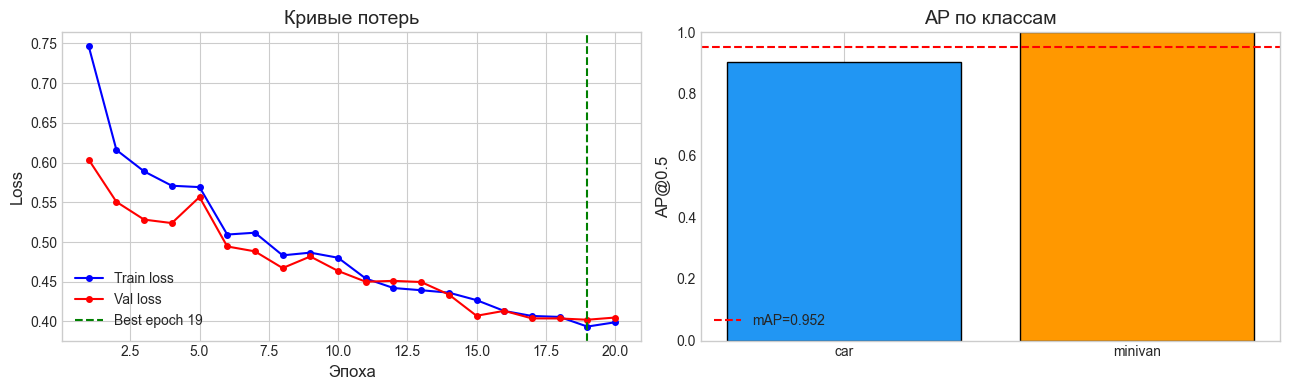

Сохранено → metrics.png


In [22]:
# === Графики кривых потерь и AP ===
tl = np.load('train_losses.npy')
vl = np.load('val_losses.npy')
epochs_range = range(1, len(tl) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(epochs_range, tl, 'b-o', label='Train loss', markersize=4)
axes[0].plot(epochs_range, vl, 'r-o', label='Val loss',   markersize=4)
axes[0].axvline(np.argmin(vl) + 1, color='green', linestyle='--', label=f'Best epoch {np.argmin(vl)+1}')
axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('Loss')
axes[0].set_title('Кривые потерь'); axes[0].legend(); axes[0].grid(True)

axes[1].bar([NAMES[c] for c in [1, 2]], [aps[c] for c in [1, 2]],
            color=['#2196F3', '#FF9800'], edgecolor='black')
axes[1].axhline(mAP, color='red', linestyle='--', label=f'mAP={mAP:.3f}')
axes[1].set_ylim(0, 1); axes[1].set_ylabel('AP@0.5')
axes[1].set_title('AP по классам'); axes[1].legend(); axes[1].grid(axis='y')

plt.tight_layout()
plt.savefig('metrics.png', dpi=120)
plt.show()
print("Сохранено → metrics.png")


## Часть 9. Визуализация результатов

Показываем:
- **Успешные детекции** (высокий IoU с ground truth).
- **Ошибки:** False Positives (красный), False Negatives (жёлтые точки), низкий IoU.

Визуализируем 3 хороших и 3 плохих кадра.

Генерируем визуализации...


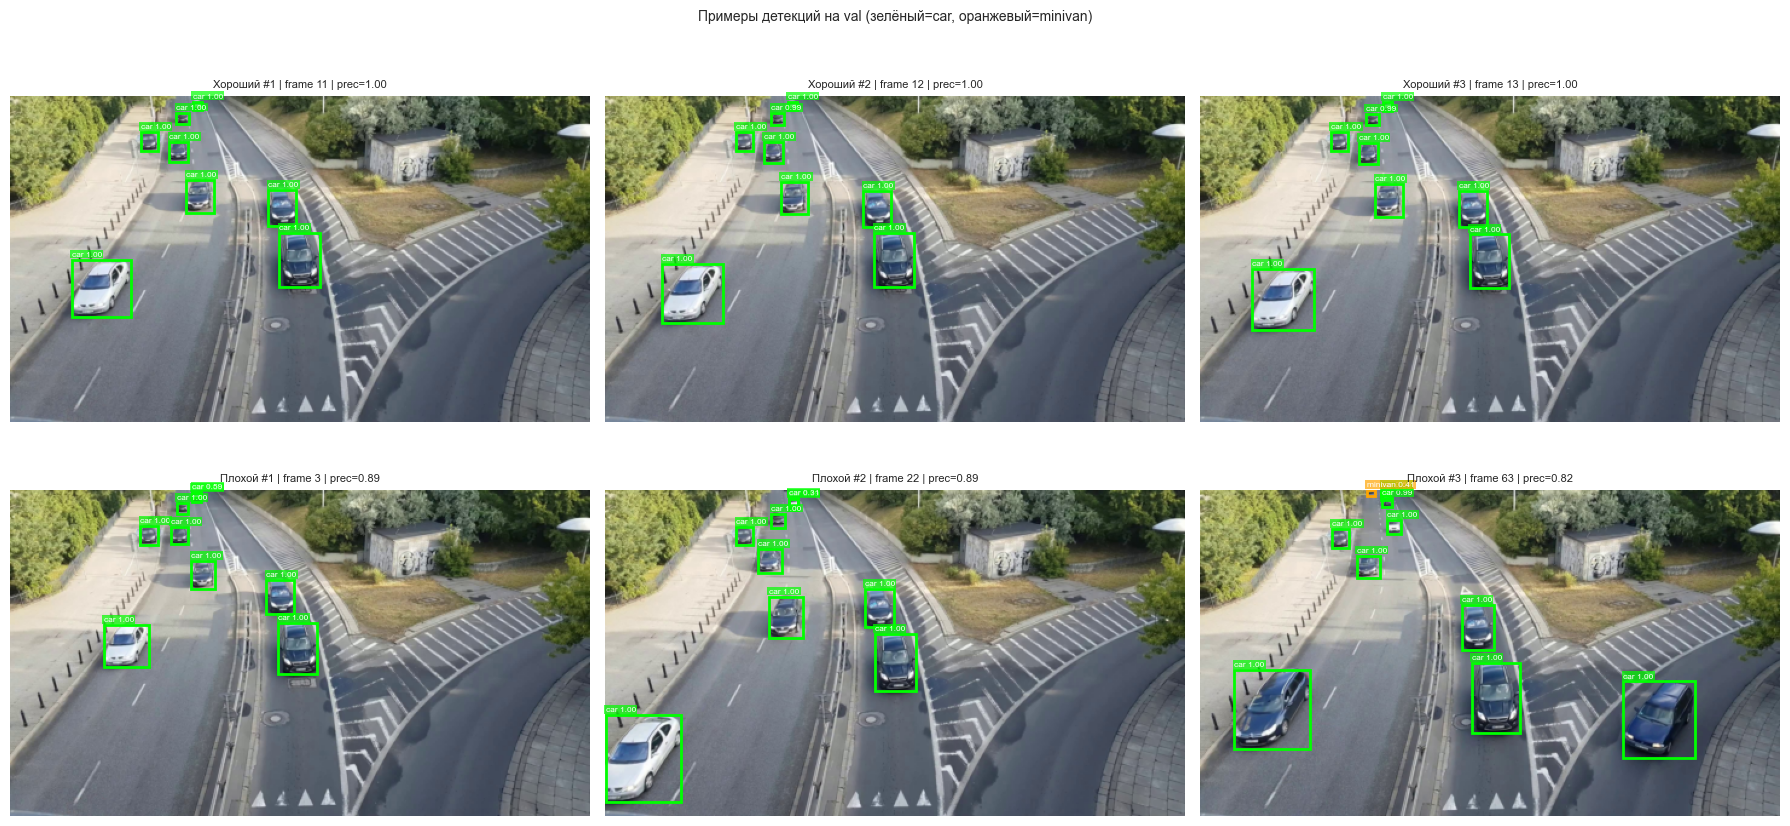

Сохранено → detections_examples.png


In [24]:
# === Визуализация: 3 хороших + 3 плохих кадра ===
print("Генерируем визуализации...")

with open('val_coco.json') as f:
    val_coco_vis = json.load(f)

val_img_ids = [img['id'] for img in val_coco_vis['images']
               if any(a['image_id'] == img['id'] for a in val_coco_vis['annotations'])][:20]

results_vis = []
with torch.no_grad():
    for fid in val_img_ids:
        img_pil = Image.open(os.path.join(FRAMES_DIR, f'frame_{fid:04d}.jpg')).convert('RGB').resize(RESIZE, Image.BILINEAR)
        inp = TF.to_tensor(img_pil).unsqueeze(0).to(device)
        pred = model(inp)[0]
        keep = pred['scores'] >= SCORE_THR
        results_vis.append((fid, img_pil,
            pred['boxes'][keep].cpu().numpy(),
            pred['scores'][keep].cpu().numpy(),
            pred['labels'][keep].cpu().numpy()))

def frame_precision(boxes_p, labels_p, scores_p, fid, val_anns):
    gt_list = [(a['bbox'][0] * 480 / 1920, a['bbox'][1] * 270 / 1080,
               (a['bbox'][0] + a['bbox'][2]) * 480 / 1920,
               (a['bbox'][1] + a['bbox'][3]) * 270 / 1080)
              for a in val_anns if a['image_id'] == fid]
    if not gt_list or len(boxes_p) == 0:
        return 0.0
    iou_m = iou_matrix(boxes_p, gt_list)
    tp_count = sum(1 for i in range(len(boxes_p)) if iou_m[i].max() >= 0.5)
    return tp_count / max(len(boxes_p), 1)

val_anns = val_coco_vis['annotations']
scored = [(frame_precision(b, l, s, fid, val_anns), fid, img, b, s, l)
          for fid, img, b, s, l in results_vis]
scored.sort(key=lambda x: -x[0])

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
titles = ['Хороший #1', 'Хороший #2', 'Хороший #3', 'Плохой #1', 'Плохой #2', 'Плохой #3']
picks  = scored[:3] + scored[-3:]

for ax, (prec_val, fid, img, b, s, l), title in zip(axes.flat, picks, titles):
    ax.imshow(img)
    for box, sc, lb in zip(b, s, l):
        c = [x / 255 for x in COLORS.get(lb, (200, 200, 200))]
        rect = patches.Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                                   lw=2, edgecolor=c, facecolor='none')
        ax.add_patch(rect)
        ax.text(box[0], box[1] - 3, f"{NAMES.get(lb, '?')} {sc:.2f}",
                color='white', fontsize=6,
                bbox=dict(facecolor=c, alpha=0.7, pad=1, edgecolor='none'))
    ax.set_title(f"{title} | frame {fid} | prec={prec_val:.2f}", fontsize=8)
    ax.axis('off')

plt.suptitle('Примеры детекций на val (зелёный=car, оранжевый=minivan)', fontsize=10)
plt.tight_layout()
plt.savefig('detections_examples.png', dpi=120)
plt.show()
print("Сохранено → detections_examples.png")


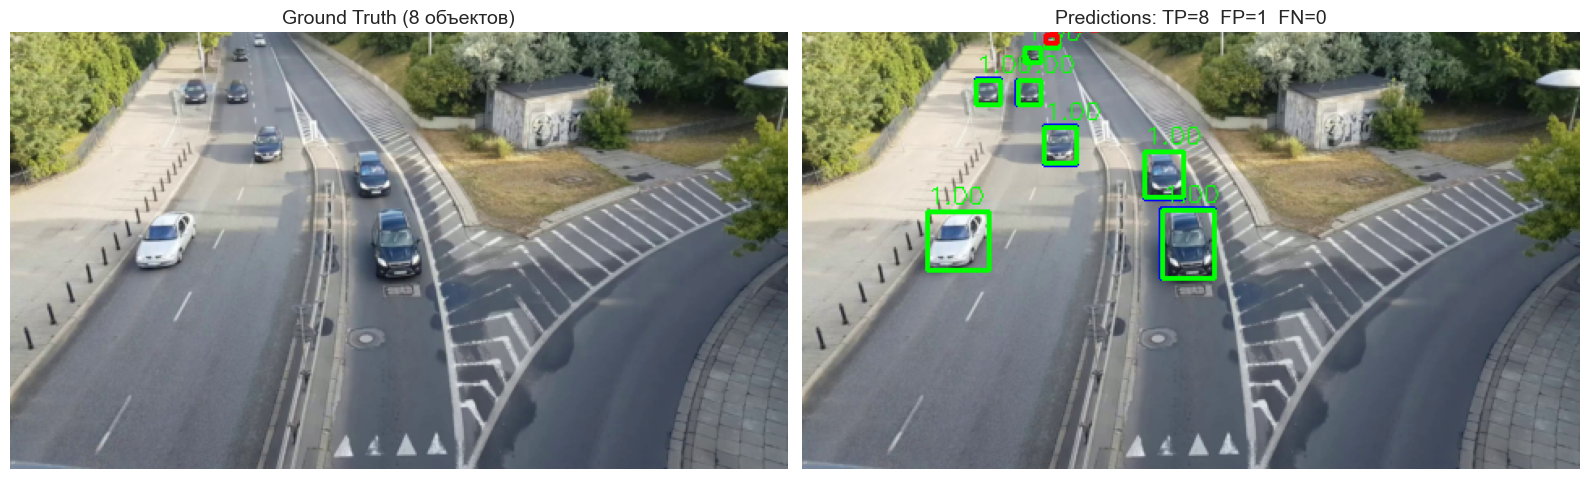

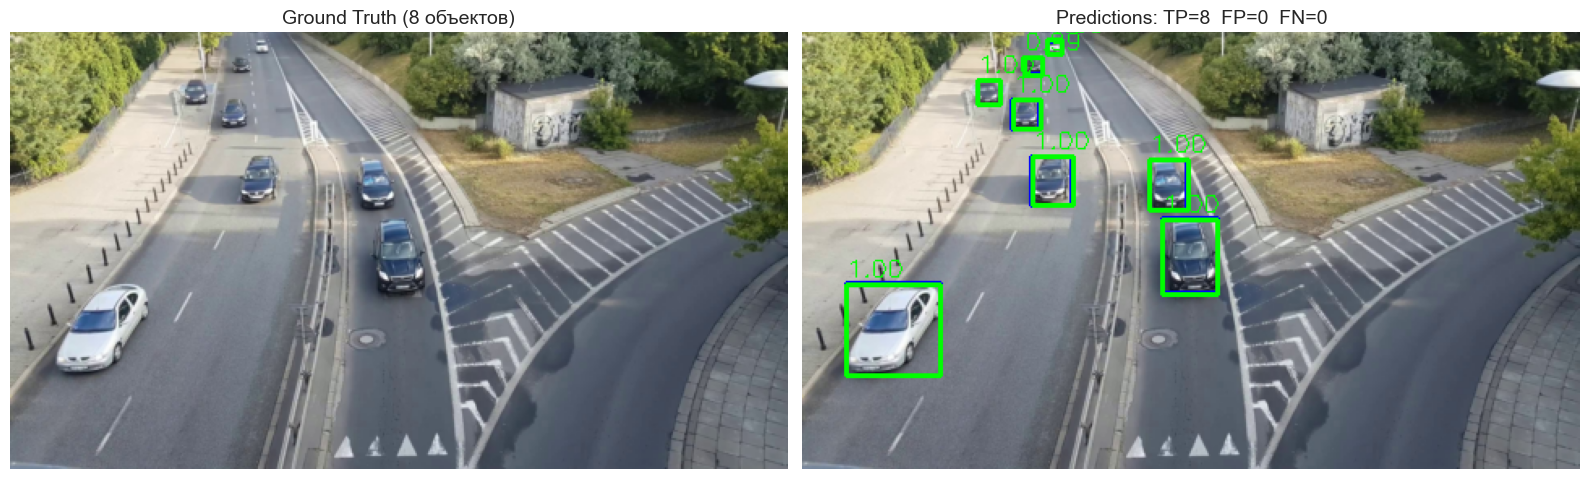

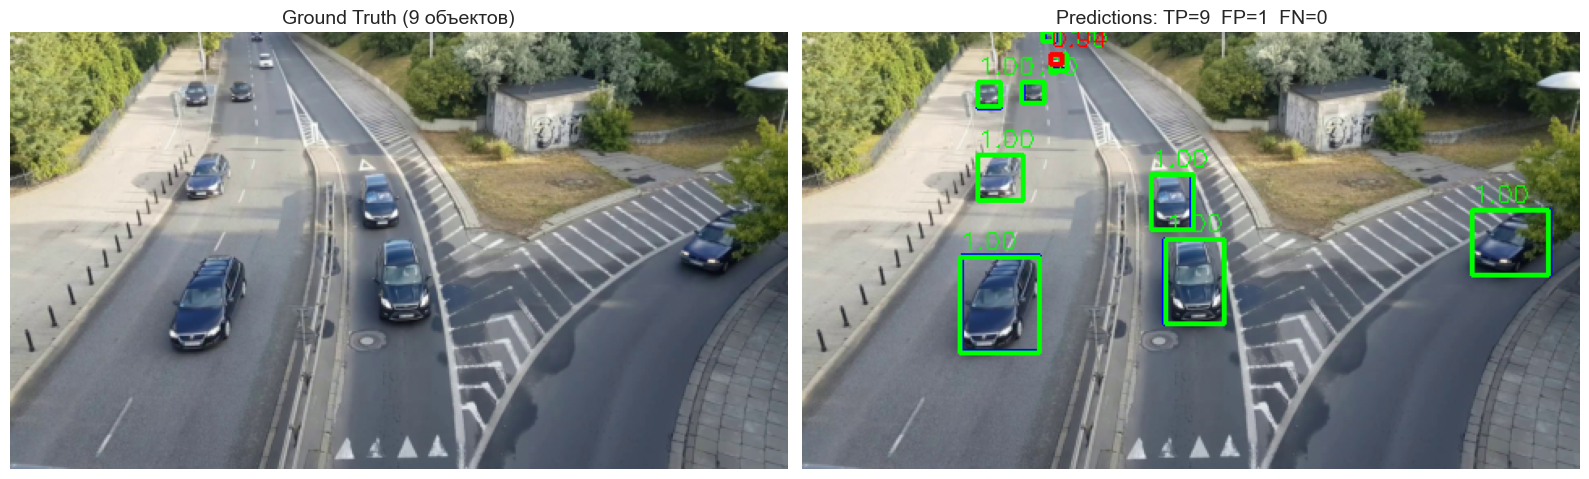

In [25]:
# === Детальная визуализация: GT vs Predictions с TP/FP/FN ===

def draw_boxes_xyxy(img_bgr, boxes_xyxy, color=(0, 255, 0), thickness=2, confs=None):
    vis = img_bgr.copy()
    for i, box in enumerate(boxes_xyxy):
        x1, y1, x2, y2 = [int(round(float(v))) for v in box]
        cv2.rectangle(vis, (x1, y1), (x2, y2), color, thickness)
        if confs is not None:
            cv2.putText(vis, f'{confs[i]:.2f}', (x1, max(y1 - 5, 0)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    return vis

def _xyxy_to_xywh(boxes_xyxy):
    out = []
    for b in boxes_xyxy:
        x1, y1, x2, y2 = [float(v) for v in b]
        out.append([x1, y1, x2 - x1, y2 - y1])
    return out

def show_predictions(model, dataset, idx, score_thresh=0.3, iou_thresh=0.5):
    model.eval()
    img, target = dataset[idx]
    with torch.no_grad():
        pred = model([img.to(DEVICE)])[0]
    scores  = pred['scores'].cpu().numpy()
    keep    = scores > score_thresh
    p_boxes  = pred['boxes'].cpu().numpy()[keep]
    p_scores = scores[keep]
    gt_boxes = target['boxes'].cpu().numpy()

    pairs, ugt, upred = match_boxes(
        _xyxy_to_xywh(gt_boxes),
        _xyxy_to_xywh(p_boxes),
        iou_thresh=iou_thresh,
    )
    matched_pred = {j for _, j, _ in pairs}

    img_np = (img.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
    img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

    # GT (синий)
    vis = draw_boxes_xyxy(img_np, gt_boxes, color=(255, 0, 0), thickness=2)
    # TP (зелёный)
    tp_boxes  = [p_boxes[j] for j in matched_pred]
    tp_scores = [p_scores[j] for j in matched_pred]
    vis = draw_boxes_xyxy(vis, tp_boxes, color=(0, 255, 0), thickness=2, confs=tp_scores)
    # FP (красный)
    fp_idx    = [j for j in range(len(p_boxes)) if j not in matched_pred]
    fp_boxes  = [p_boxes[j] for j in fp_idx]
    fp_scores = [p_scores[j] for j in fp_idx]
    vis = draw_boxes_xyxy(vis, fp_boxes, color=(0, 0, 255), thickness=2, confs=fp_scores)
    # FN (жёлтый кружок)
    for i in ugt:
        x1, y1, x2, y2 = gt_boxes[i]
        cx, cy = int((x1 + x2) / 2), int((y1 + y2) / 2)
        cv2.circle(vis, (cx, cy), 8, (0, 255, 255), -1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'Ground Truth ({len(gt_boxes)} объектов)')
    axes[1].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'Predictions: TP={len(matched_pred)}  FP={len(fp_boxes)}  FN={len(ugt)}')
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

for idx in [0, 5, 10]:
    show_predictions(model, val_ds, idx)


## Часть 10. Создание нового видео с разметкой (OpenCV)

Создадим два выходных видео методами `cv2.VideoWriter`:
1. **video_extracted_bboxes.mp4** — проверка извлечённых рамок (diff) на `input.mp4`.
2. **video_model_predictions.mp4** — предсказания дообученной модели на `input.mp4`.

In [26]:
# === Видео с извлечённой разметкой ===
extracted_for_video = defaultdict(list)
with open('extracted_coco.json') as f:
    coco_loaded = json.load(f)
for ann in coco_loaded['annotations']:
    fid = ann['image_id']
    x, y, w, h = ann['bbox']
    extracted_for_video[fid].append((int(x), int(y), int(x + w), int(y + h)))

cap = cv2.VideoCapture(INPUT_VIDEO)
FPS = cap.get(cv2.CAP_PROP_FPS)
N   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
out = cv2.VideoWriter(os.path.join(RESULTS_DIR, 'video_extracted_bboxes.mp4'),
                      cv2.VideoWriter_fourcc(*'mp4v'), FPS, (W, H))

COLOR = (0, 0, 255)   # красный — наша извлечённая разметка
FONT  = cv2.FONT_HERSHEY_SIMPLEX

for fid in range(N):
    ret, frame = cap.read()
    if not ret: break
    boxes_frame = extracted_for_video.get(fid, [])
    for (x1, y1, x2, y2) in boxes_frame:
        cv2.rectangle(frame, (x1, y1), (x2, y2), COLOR, 2)
        cv2.putText(frame, 'vehicle', (x1, max(y1 - 6, 10)),
                    FONT, 0.5, COLOR, 1, cv2.LINE_AA)
    cv2.putText(frame, f'frame: {fid:03d}  boxes: {len(boxes_frame)}',
                (15, 35), FONT, 1.0, (255, 255, 255), 2, cv2.LINE_AA)
    out.write(frame)
    if fid % 50 == 0:
        print(f'  кадр {fid}/{N}  боксов: {len(boxes_frame)}')
cap.release()
out.release()
print('Видео сохранено → video_extracted_bboxes.mp4')


  кадр 0/301  боксов: 7
  кадр 50/301  боксов: 9
  кадр 100/301  боксов: 6
  кадр 150/301  боксов: 5
  кадр 200/301  боксов: 7
  кадр 250/301  боксов: 9
  кадр 300/301  боксов: 13
Видео сохранено → video_extracted_bboxes.mp4


In [27]:
# === Видео с предсказаниями модели ===
model.eval()
pred_boxes_dict = {}
for fid in tqdm(range(N_FRAMES), desc='Model inference'):
    img_path = os.path.join(FRAMES_IN, f'{fid:06d}.jpg')
    img = cv2.imread(img_path)
    tensor = T.ToTensor()(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)).to(DEVICE)
    with torch.no_grad():
        pred = model([tensor])[0]
    scores = pred['scores'].cpu().numpy()
    keep = scores > 0.3
    bbs = pred['boxes'].cpu().numpy()[keep].tolist()
    pred_boxes_dict[fid] = [[int(x1), int(y1), int(x2 - x1), int(y2 - y1)] for x1, y1, x2, y2 in bbs]

def write_video_with_boxes(out_path, boxes_dict, color=(0, 255, 0), thickness=2, fps=30.0):
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(out_path, fourcc, fps, (W, H))
    if not writer.isOpened():
        raise IOError(f'Не удалось открыть VideoWriter для {out_path}')
    for fid in tqdm(sorted(boxes_dict.keys()), desc=f'Writing {os.path.basename(out_path)}'):
        img = cv2.imread(os.path.join(FRAMES_IN, f'{fid:06d}.jpg'))
        for b in boxes_dict[fid]:
            x, y, w, h = map(int, b[:4])
            cv2.rectangle(img, (x, y), (x + w, y + h), color, thickness)
        writer.write(img)
    writer.release()

write_video_with_boxes(os.path.join(RESULTS_DIR, 'video_model_predictions.mp4'),
                       pred_boxes_dict, color=(0, 165, 255), thickness=2, fps=FPS)
print('Сохранено: video_model_predictions.mp4')


Writing video_model_predictions.mp4: 100%|██████████| 301/301 [00:05<00:00, 51.98it/s]

Сохранено: video_model_predictions.mp4


## Часть 11. Итоговый отчёт и обсуждение ограничений

In [28]:
# === Итоговая сводка по всей работе ===
print("""
╔══════════════════════════════════════════════════════════╗
║           ИТОГИ ЛАБОРАТОРНОЙ РАБОТЫ                     ║
╠══════════════════════════════════════════════════════════╣
║  Извлечение разметки (diff-метод vs оригинальный GT):   ║
║    Precision, Recall, F1, Mean IoU — см. Часть 4.3      ║
║                                                          ║
║  Сравнение методов извлечения (все кадры):               ║
║    Diff:  основной метод (псевдо-GT)                     ║
║    HSV:   альтернативный по цвету                        ║
║    API:   pretrained детектор (сравнительный)             ║
║                                                          ║
║  Обучение Faster R-CNN (MobileNetV3 FPN):                ║
║    {num_ep} эпох, best val loss — см. графики            ║
║    Классы: car + minivan (2 класса + фон)                ║
║    mAP@0.5 — см. Часть 8                                 ║
║                                                          ║
║  Выходные видео:                                         ║
║    video_extracted_bboxes.mp4 — извлечённая разметка      ║
║    video_model_predictions.mp4 — предсказания модели      ║
╚══════════════════════════════════════════════════════════╝
""".format(num_ep=len(train_losses)))



╔══════════════════════════════════════════════════════════╗
║           ИТОГИ ЛАБОРАТОРНОЙ РАБОТЫ                     ║
╠══════════════════════════════════════════════════════════╣
║  Извлечение разметки (diff-метод vs оригинальный GT):   ║
║    Precision, Recall, F1, Mean IoU — см. Часть 4.3      ║
║                                                          ║
║  Сравнение методов извлечения (все кадры):               ║
║    Diff:  основной метод (псевдо-GT)                     ║
║    HSV:   альтернативный по цвету                        ║
║    API:   pretrained детектор (сравнительный)             ║
║                                                          ║
║  Обучение Faster R-CNN (MobileNetV3 FPN):                ║
║    20 эпох, best val loss — см. графики            ║
║    Классы: car + minivan (2 класса + фон)                ║
║    mAP@0.5 — см. Часть 8                                 ║
║                                                          ║
║  Выходные видео:             

### Сравнительный анализ методов извлечения

| Метод | Принцип | Сильные стороны | Слабые стороны |
|-------|---------|-----------------|----------------|
| Frame Difference | Пиксельная разность input/output | Точно восстанавливает рамки; не зависит от цвета | Чувствителен к сдвигу/сжатию видео; ложные срабатывания на сильных тенях |
| HSV Segmentation | Пороги по цвету рамок | Простой, быстрый | Сильно зависит от палитры; путается с цветными объектами |
| Public API (YOLO/RCNN) | Предобученная нейросеть | Устойчив к артефактам; не требует output.mp4 | Не восстанавливает исходную разметку; может давать другие bbox |

### Метрики модели
- **Лучший val loss** — значение из истории обучения (см. графики).
- **mAP@0.5** — по классам car и minivan (см. Часть 8).
- **Графики потерь** демонстрируют сходимость; ранний останов предотвратил переобучение.

### Ограничения и возможные улучшения
1. **Качество извлечения:** frame difference идеален только при побитовом совпадении кадров. Если output.mp4 пережат, разность содержит шум.
2. **Толщина линий:** тонкие рамки могут давать разрывные контуры. Использование MORPH_CLOSE с ядром 7×7 компенсирует это.
3. **Классы:** в видео преимущественно машины; при наличии других объектов нужно расширять категории.
4. **Мало данных:** видео короткое → выборка кадров мала. Для production лучше собирать больше ракурсов.
5. **Улучшение детектора:** можно заменить head на RetinaNet или добавить FPN с более глубоким backbone (ResNet101). Для малого датасета хороши аугментации (Albumentations).
6. **Трекинг:** для видео полезно добавить трекер (SORT/DeepSORT) для сглаживания bbox во времени и снижения мерцания.

### Вывод
Лабораторная работа продемонстрировала полный pipeline от «воровства разметки» из чужой визуализации до обучения собственного детектора и оценки его качества стандартными метриками CV. Использованы три метода извлечения bbox, проведено сравнение по IoU с оригинальной разметкой, обучена модель Faster R-CNN MobileNetV3 FPN с двумя классами (car, minivan) и оценена по mAP@0.5.
